# Medium-sized Inversions
Here, we visualize the inversions that were identified for the `medium` treatment across the range of depths.

In [28]:
library(ggplot2)
options(warn = -1)
read_data <- function(size_treatment, depth){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(
        paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
        header = T
    )[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- paste("pooled", depth, size_treatment, sep = "_")
    }

    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}

plot_data <- function(data, size_treatment, depth){
    axis_ticks <- c(paste0("sample_", sprintf("%02d", 1:10), ".", depth), "simulated_inversions")
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste(size_treatment, depth), x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

Set a global variable `.size` to `"medium"` to avoid writing it each time

In [29]:
.size <- "medium"

## 0.5X depth

In [30]:
depth_05X <- read_data(.size, "05X")
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
12,3R,26216293,26389606,simulated_inversions
13,3L,1700629,1761806,simulated_inversions
14,3L,6119288,6436722,simulated_inversions
15,3L,9943175,10123730,simulated_inversions
16,3L,21061086,21499573,simulated_inversions
17,2L,20404849,20474311,pooled_05X_medium


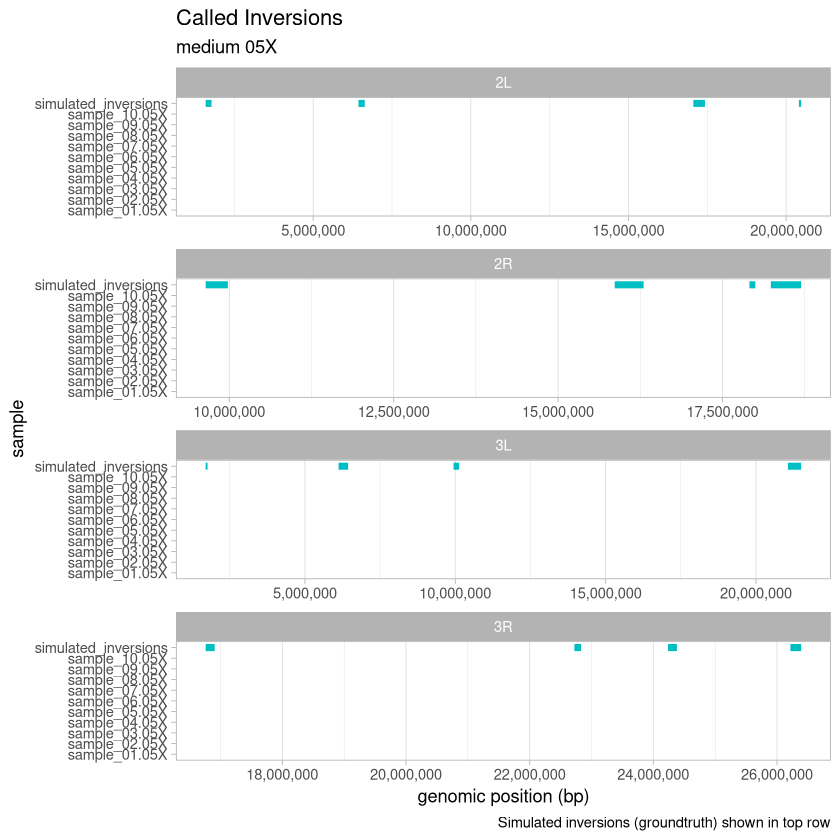

In [31]:
plot_data(depth_05X, .size, "05X")

## 2X Depth

In [32]:
depth_2X <- read_data(.size, "2X")
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
35,3R,22722815,22831351,sample_06.2X
36,2L,17056242,17424245,sample_05.2X
37,3R,22722815,22831351,sample_05.2X
38,2L,20404849,20474311,pooled_2X_medium
39,3L,1700628,1761806,pooled_2X_medium
40,2R,17910284,18000549,pooled_2X_medium


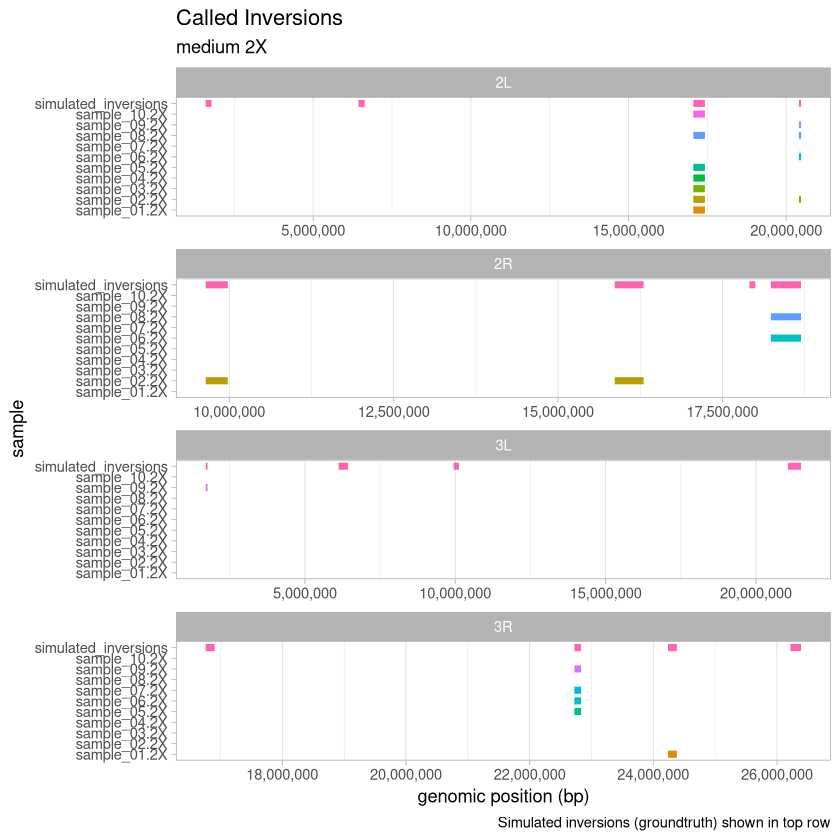

In [33]:
plot_data(depth_2X, .size, "2X")

## 5X Depth

In [34]:
depth_5X <- read_data(.size, "5X")
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
76,2R,9640873,9978281,sample_08.5X
77,2R,18236489,18696638,sample_08.5X
78,3R,22722815,22831351,sample_08.5X
79,2L,20404849,20474311,pooled_5X_medium
80,3L,1700628,1761806,pooled_5X_medium
81,2R,17910284,18000549,pooled_5X_medium


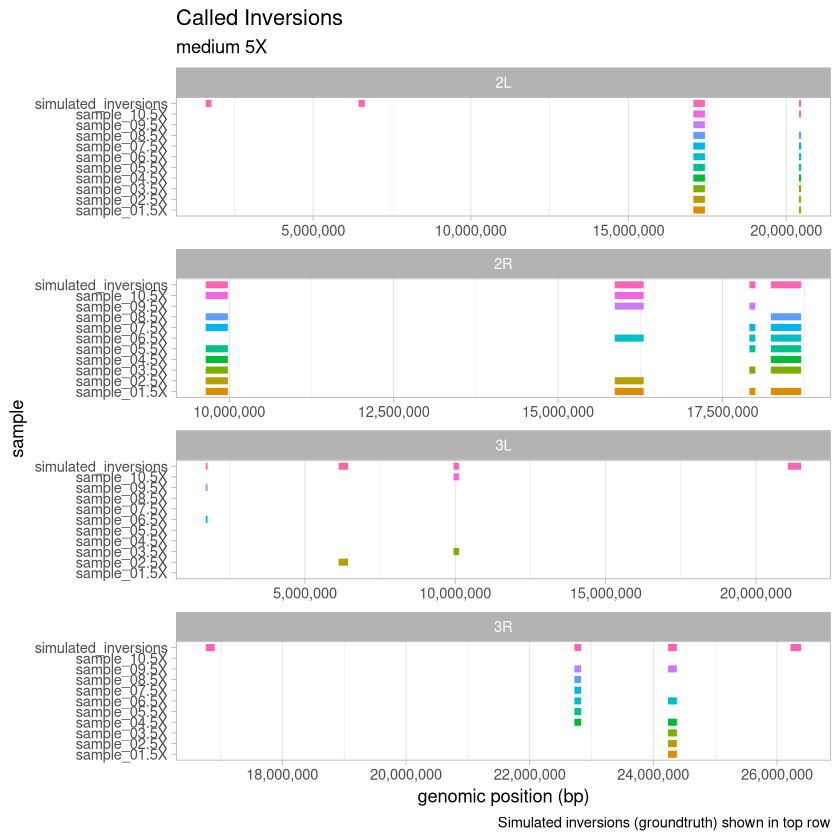

In [35]:
plot_data(depth_5X, .size, "5X")

## 10X Depth

In [36]:
depth_10X <- read_data(.size, "10X")
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
92,3R,22722815,22831351,sample_04.10X
93,3R,24237378,24380767,sample_04.10X
94,2L,20404852,20474311,pooled_10X_medium
95,3L,1700627,1761806,pooled_10X_medium
96,2R,17910284,18000549,pooled_10X_medium
97,3R,22722815,22831351,pooled_10X_medium


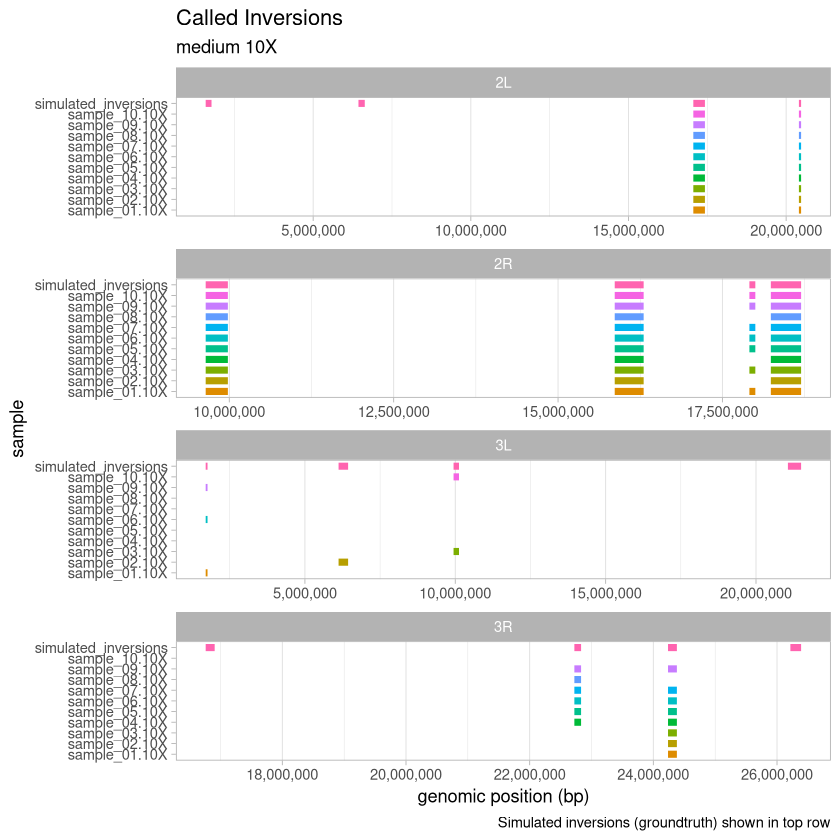

In [37]:
plot_data(depth_10X, .size, "10X")

## 20X Depth

In [38]:
depth_20X <- read_data(.size, "20X")
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
98,3R,24237375,24380767,sample_01.20X
99,2L,20404852,20474311,pooled_20X_medium
100,3L,1700627,1761806,pooled_20X_medium
101,2R,17910284,18000549,pooled_20X_medium
102,3R,22722815,22831351,pooled_20X_medium
103,3R,24237375,24380767,pooled_20X_medium


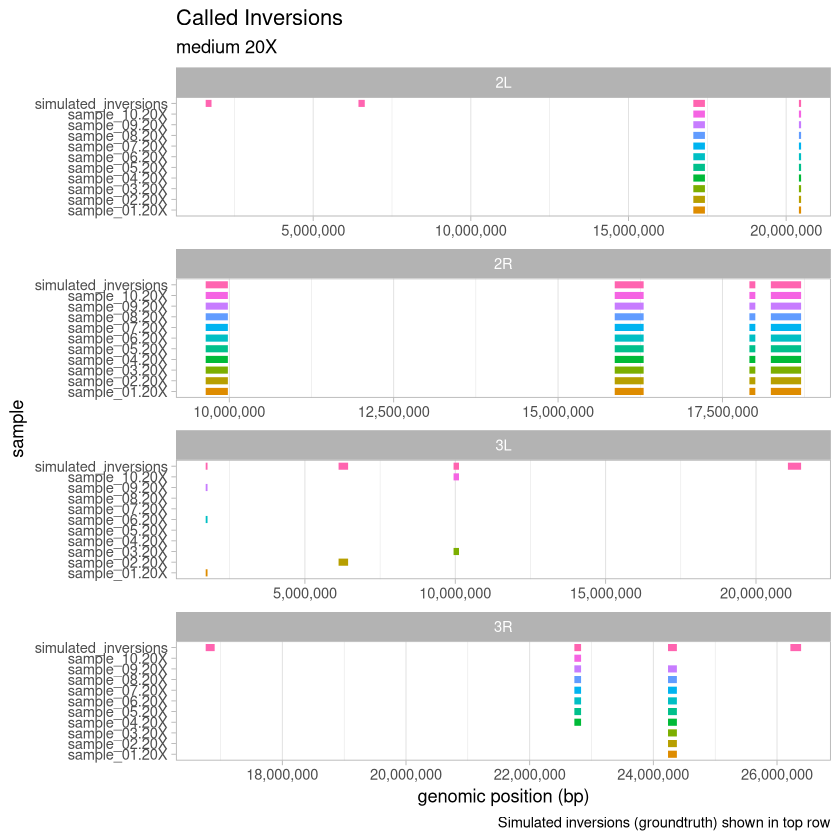

In [39]:
plot_data(depth_20X, .size, "20X")